<a href="https://colab.research.google.com/github/WiLLiAMkao-03/Data-Portfolio---William-Ofori-/blob/main/Ofori_William_wao20002_OPIM_5604_HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The work contained and presented here is my work and my work alone

# ENVIRONMENT SETUP

The work contained and presented here is my work and my work alone

In [ ]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm


In [ ]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# LOAD THE DATA - TELCO CHURN

In [ ]:
# read data
# on the lefthand side, navigate to your data and copy the path
df = pd.read_csv('/content/drive/MyDrive/OPIM 5604 Python/Datasets/Telco_customer_churn.csv')

1. Read in the Telco dataset and determine how many rows and columns it has.

In [ ]:
# shape
# shows how many rows and columns
# this sample has 5000 rows and 14 columns
df.shape

(7043, 18)

There are 7043 rows and 18 columns in this dataset

In [ ]:
# Preview
print(df.head())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

In [ ]:
# Display the first few rows and unique values of the 'Churn Value' target variable
print(df.head())
print("\nUnique values for 'Churn Value':")
print(df['Churn Value'].unique())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

# DECISION TREE- MANUAL MATH

In [ ]:
# Look at counts of 0 and 1 values for 'Churn Value' to check the distribution
churn_counts = df['Churn Value'].value_counts()
print("Counts of Churn Value (0s and 1s):")
print(churn_counts)

Counts of Churn Value (0s and 1s):
Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Identify all remaining categorical columns (object type) for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'CustomerID' and 'Churn Label' from encoding as they are identifiers/redundant
categorical_cols = [col for col in categorical_cols if col not in ['CustomerID', 'Churn Label']]

print(f"Categorical columns to encode: {categorical_cols}")

# Apply one-hot encoding to the identified categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows to see the changes after encoding
print(df.head())

Categorical columns to encode: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Electronic Check']
   CustomerID  Tenure Months  Monthly Charges Churn Label  Churn Value  \
0  3668-QPYBK              2            53.85         Yes            1   
1  9237-HQITU              2            70.70         Yes            1   
2  9305-CDSKC              8            99.65         Yes            1   
3  7892-POOKP             28           104.80         Yes            1   
4  0280-XJGEX             49           103.70         Yes            1   

   Gender_Male  Senior Citizen_Yes  Partner_Yes  Dependents_Yes  \
0         True               False        False           False   
1        False               False        False            True   
2        False               False        False            True   
3        False               False    

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable
target = 'Churn Value' # Corrected target variable
# Define features by dropping the target variable, 'Churn Label' (redundant with 'Churn Value'), and 'CustomerID' (an identifier)
features = df.drop([target, 'Churn Label', 'CustomerID'], axis=1)
target_variable = df[target]

# Split the data into 80% for training+validation and 20% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(features, target_variable, test_size=0.2, random_state=42)

# Split the 80% training+validation data into 75% training (0.75 * 0.8 = 0.6 total)
# and 25% validation (0.25 * 0.8 = 0.2 total)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42) # 0.25 of X_train_val

# Print the shapes of the resulting datasets
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (4225, 18) (4225,)
Validation set shape: (1409, 18) (1409,)
Test set shape: (1409, 18) (1409,)


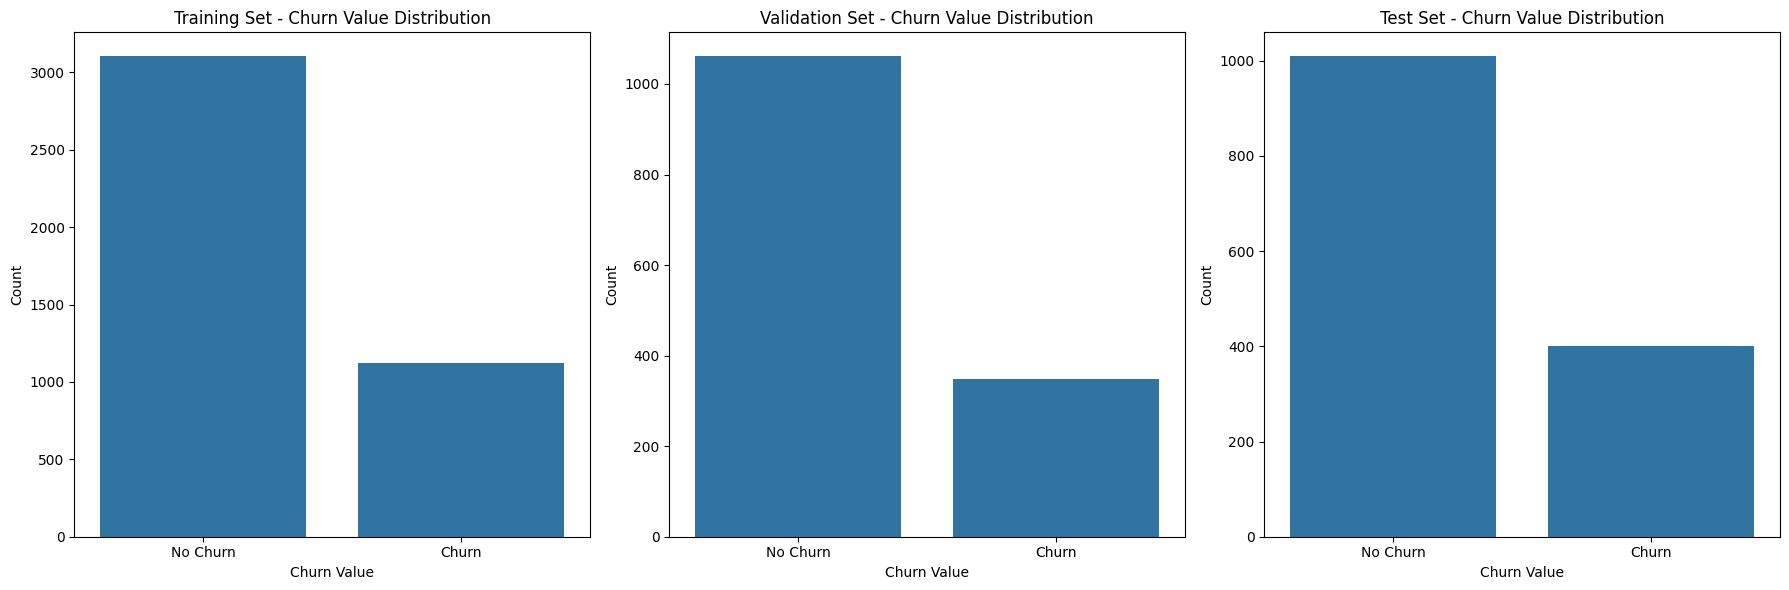

Training set Churn Value counts and percentages:
Churn Value
0    3104
1    1121
Name: count, dtype: int64
Churn Value
0    73.47
1    26.53
Name: proportion, dtype: float64

Validation set Churn Value counts and percentages:
Churn Value
0    1061
1     348
Name: count, dtype: int64
Churn Value
0    75.3
1    24.7
Name: proportion, dtype: float64

Test set Churn Value counts and percentages:
Churn Value
0    1009
1     400
Name: count, dtype: int64
Churn Value
0    71.61
1    28.39
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the features and target for plotting
train_data = X_train.copy()
train_data['Churn Value'] = y_train # Changed label

val_data = X_val.copy()
val_data['Churn Value'] = y_val # Changed label

test_data = X_test.copy()
test_data['Churn Value'] = y_test # Changed label

# Plot the distribution of 'Churn Value' in each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x='Churn Value', ax=axs[0])
axs[0].set_title('Training Set - Churn Value Distribution') # Changed title
axs[0].set_xlabel('Churn Value') # Changed label
axs[0].set_ylabel('Count')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No Churn', 'Churn']) # Changed labels

sns.countplot(data=val_data, x='Churn Value', ax=axs[1])
axs[1].set_title('Validation Set - Churn Value Distribution') # Changed title
axs[1].set_xlabel('Churn Value') # Changed label
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No Churn', 'Churn']) # Changed labels

sns.countplot(data=test_data, x='Churn Value', ax=axs[2])
axs[2].set_title('Test Set - Churn Value Distribution') # Changed title
axs[2].set_xlabel('Churn Value') # Changed label
axs[2].set_ylabel('Count')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No Churn', 'Churn']) # Changed labels

plt.tight_layout()
plt.show()

# Print counts and percentages for each partition
print("Training set Churn Value counts and percentages:") # Changed label
train_counts = train_data['Churn Value'].value_counts()
train_percentages = train_data['Churn Value'].value_counts(normalize=True) * 100
print(train_counts)
print(train_percentages.round(2)) # Round percentages to 2 decimal places


print("\nValidation set Churn Value counts and percentages:") # Changed label
val_counts = val_data['Churn Value'].value_counts()
val_percentages = val_data['Churn Value'].value_counts(normalize=True) * 100
print(val_counts)
print(val_percentages.round(2)) # Round percentages to 2 decimal places


print("\nTest set Churn Value counts and percentages:") # Changed label
test_counts = test_data['Churn Value'].value_counts()
test_percentages = test_data['Churn Value'].value_counts(normalize=True) * 100
print(test_counts)
print(test_percentages.round(2)) # Round percentages to 2 decimal places

Now that the data is prepared with the correct target variable and split, and all features are numerical, the manual calculation of Gini impurity and Information Gain should run correctly for all features.

In [ ]:
# Manual calculation of the first split in a decision tree

# Calculate the overall Gini impurity of the target variable
total_instances = len(y_train)
churn_value_counts = y_train.value_counts() # Changed variable name
gini_churn_value = 1 - sum((count / total_instances) ** 2 for count in churn_value_counts) # Changed variable name

print(f"Overall Gini Impurity of Churn Value: {gini_churn_value:.4f}") # Changed label

# Let's consider a potential split, for example, by 'Monthly Charges' at a certain threshold
# We need to find potential split points. A common approach is to consider the midpoints
# between sorted unique values. For simplicity, let's pick an arbitrary threshold for now.
monthly_charges_threshold = 50 # Example threshold, changed from Income to Monthly Charges as Income is not a feature in this dataset

# Split the training data based on the monthly charges threshold
left_split_indices = X_train[X_train['Monthly Charges'] <= monthly_charges_threshold].index # Changed feature
right_split_indices = X_train[X_train['Monthly Charges'] > monthly_charges_threshold].index # Changed feature

y_train_left_split = y_train.loc[left_split_indices]
y_train_right_split = y_train.loc[right_split_indices]

# Calculate Gini impurity for the left split (Monthly Charges <= 50)
total_left = len(y_train_left_split)
if total_left > 0:
    left_counts = y_train_left_split.value_counts()
    gini_left = 1 - sum((count / total_left) ** 2 for count in left_counts)
else:
    gini_left = 0 # If no instances in this split, impurity is 0

# Calculate Gini impurity for the right split (Monthly Charges > 50)
total_right = len(y_train_right_split)
if total_right > 0:
    right_counts = y_train_right_split.value_counts()
    gini_right = 1 - sum((count / total_right) ** 2 for count in right_counts)
else:
    gini_right = 0 # If no instances in this split, impurity is 0


# Calculate the weighted average Gini impurity after the split
weighted_gini_split = (total_left / total_instances) * gini_left + (total_right / total_instances) * gini_right

# Calculate the Information Gain (reduction in Gini impurity)
information_gain = gini_churn_value - weighted_gini_split # Changed variable name

print(f"\nSplit based on Monthly Charges <= {monthly_charges_threshold}:") # Changed label
print(f"  Gini Impurity (Monthly Charges <= {monthly_charges_threshold}): {gini_left:.4f} (n={total_left})") # Changed label
print(f"  Gini Impurity (Monthly Charges > {monthly_charges_threshold}): {gini_right:.4f} (n={total_right})") # Changed label
print(f"  Weighted Average Gini Impurity: {weighted_gini_split:.4f}")
print(f"  Information Gain: {information_gain:.4f}")

# To find the best split, you would repeat this process for all potential split points
# for each feature and select the split with the highest information gain.

Overall Gini Impurity of Churn Value: 0.3899

Split based on Monthly Charges <= 50:
  Gini Impurity (Monthly Charges <= 50): 0.2602 (n=1392)
  Gini Impurity (Monthly Charges > 50): 0.4353 (n=2833)
  Weighted Average Gini Impurity: 0.3776
  Information Gain: 0.0122


/tmp/ipykernel_8197/1925788379.py:6: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_churn_value = 1 - sum((count / total_instances) ** 2 for count in churn_value_counts) # Changed variable name
/tmp/ipykernel_8197/1925788379.py:26: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_left = 1 - sum((count / total_left) ** 2 for count in left_counts)
/tmp/ipykernel_8197/1925788379.py:34: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_right = 1 - sum((count / total_right) ** 2 for count in right_counts)


Now, let's find the best split for 'Monthly Charges' across all its unique values.

In [ ]:
# Find potential split points for 'Monthly Charges'
# Potential split points are the unique values of the feature
potential_splits = sorted(X_train['Monthly Charges'].unique()) # Changed feature from Income

best_gini = float('inf')
best_threshold = None

# Calculate the overall Gini impurity (already calculated in the previous cell, but recalculating for clarity)
total_instances = len(y_train)
churn_value_counts = y_train.value_counts() # Changed variable name
gini_churn_value = 1 - sum((count / total_instances) ** 2 for count in churn_value_counts) # Changed variable name


# Iterate through each potential split point
for threshold in potential_splits:
    # Split the training data based on the current threshold
    left_split_indices = X_train[X_train['Monthly Charges'] <= threshold].index # Changed feature
    right_split_indices = X_train[X_train['Monthly Charges'] > threshold].index # Changed feature

    y_train_left_split = y_train.loc[left_split_indices]
    y_train_right_split = y_train.loc[right_split_indices]

    # Calculate Gini impurity for the left split
    total_left = len(y_train_left_split)
    if total_left > 0:
        left_counts = y_train_left_split.value_counts()
        gini_left = 1 - sum((count / total_left) ** 2 for count in left_counts)
    else:
        gini_left = 0

    # Calculate Gini impurity for the right split
    total_right = len(y_train_right_split)
    if total_right > 0:
        right_counts = y_train_right_split.value_counts()
        gini_right = 1 - sum((count / total_right) ** 2 for count in right_counts)
    else:
        gini_right = 0

    # Calculate the weighted average Gini impurity after the split
    weighted_gini_split = (total_left / total_instances) * gini_left + (total_right / total_instances) * gini_right

    # Check if this split is better than the current best
    if weighted_gini_split < best_gini:
        best_gini = weighted_gini_split
        best_threshold = threshold

information_gain = gini_churn_value - best_gini # Changed variable name

print(f"Best split for Monthly Charges:") # Changed label
print(f"  Threshold: {best_threshold}")
print(f"  Weighted Average Gini Impurity: {best_gini:.4f}")
print(f"  Information Gain: {information_gain:.4f}")

/tmp/ipykernel_8197/3962145185.py:11: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_churn_value = 1 - sum((count / total_instances) ** 2 for count in churn_value_counts) # Changed variable name
/tmp/ipykernel_8197/3962145185.py:27: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_left = 1 - sum((count / total_left) ** 2 for count in left_counts)
/tmp/ipykernel_8197/3962145185.py:35: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_right = 1 - sum((count / total_right) ** 2 for count in right_counts)


Best split for Monthly Charges:
  Threshold: 69.2
  Weighted Average Gini Impurity: 0.3705
  Information Gain: 0.0194


This process is then repeated for all features and all possible split points to find the overall best first split. The code below automates this for all features.

In [ ]:
# Calculate the overall Gini impurity (from previous calculation)
total_instances = len(y_train)
churn_value_counts = y_train.value_counts() # Changed variable name
gini_churn_value = 1 - sum((count / total_instances) ** 2 for count in churn_value_counts) # Changed variable name

print(f"Overall Gini Impurity of Churn Value: {gini_churn_value:.4f}\n") # Changed label

# Create a list to store the results for each feature
results = []

# Iterate through all predictor variables
for feature in X_train.columns:
    # Find potential split points for the current feature
    # For numerical features, use unique values. For categorical (dummy) features, the split is between 0 and 1.
    if X_train[feature].dtype in ['int64', 'float64']:
        potential_splits = sorted(X_train[feature].unique())
    else: # Assuming boolean/dummy variables (which should be handled by get_dummies, but good to have a fallback)
        potential_splits = [0.5] # Split between False (0) and True (1)

    best_gini = float('inf')
    best_threshold = None

    # Iterate through each potential split point for the current feature
    for threshold in potential_splits:
        # Split the training data based on the current threshold
        left_split_indices = X_train[X_train[feature] <= threshold].index
        right_split_indices = X_train[X_train[feature] > threshold].index

        y_train_left_split = y_train.loc[left_split_indices]
        y_train_right_split = y_train.loc[right_split_indices]

        # Calculate Gini impurity for the left split
        total_left = len(y_train_left_split)
        if total_left > 0:
            left_counts = y_train_left_split.value_counts()
            gini_left = 1 - sum((count / total_left) ** 2 for count in left_counts)
        else:
            gini_left = 0

        # Calculate Gini impurity for the right split
        total_right = len(y_train_right_split)
        if total_right > 0:
            right_counts = y_train_right_split.value_counts()
            gini_right = 1 - sum((count / total_right) ** 2 for count in right_counts)
        else:
            gini_right = 0

        # Calculate the weighted average Gini impurity after the split
        weighted_gini_split = (total_left / total_instances) * gini_left + (total_right / total_instances) * gini_right

        # Check if this split is better than the current best
        if weighted_gini_split < best_gini:
            best_gini = weighted_gini_split
            best_threshold = threshold

    information_gain = gini_churn_value - best_gini # Changed variable name

    # Store the results for the current feature
    results.append({
        'Feature': feature,
        'Best Threshold': best_threshold,
        'Weighted Gini Impurity': best_gini,
        'Information Gain': information_gain
    })

# Convert the results to a pandas DataFrame and display
results_df = pd.DataFrame(results)
display(results_df.round(4)) # Display with 4 decimal places for clarity

/tmp/ipykernel_8197/4024613714.py:4: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_churn_value = 1 - sum((count / total_instances) ** 2 for count in churn_value_counts) # Changed variable name
/tmp/ipykernel_8197/4024613714.py:36: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_left = 1 - sum((count / total_left) ** 2 for count in left_counts)
/tmp/ipykernel_8197/4024613714.py:44: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  gini_right = 1 - sum((count / total_right) ** 2 for count in right_counts)


Overall Gini Impurity of Churn Value: 0.3899



,Feature,Best Threshold,Weighted Gini Impurity,Information Gain
0,Tenure Months,16.0,0.3479,0.0420
1,Monthly Charges,69.2,0.3705,0.0194
2,Gender_Male,0.5,0.3898,0.0000
3,Senior Citizen_Yes,0.5,0.3809,0.0090
4,Partner_Yes,0.5,0.3817,0.0082
5,Dependents_Yes,0.5,0.3668,0.0231
6,Multiple Lines_No phone service,0.5,0.3899,0.0000
7,Multiple Lines_Yes,0.5,0.3890,0.0009
8,Internet Service_Fiber optic,0.5,0.3521,0.0378
9,Internet Service_No,0.5,0.3679,0.0219


# Decision Trees

3. Build a decision tree model to predict churn using all predictors.


First we identify the model then fit it to the training data.  

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
# We can start with default parameters or set some like max_depth for initial exploration
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Let's look at the tree we just built.

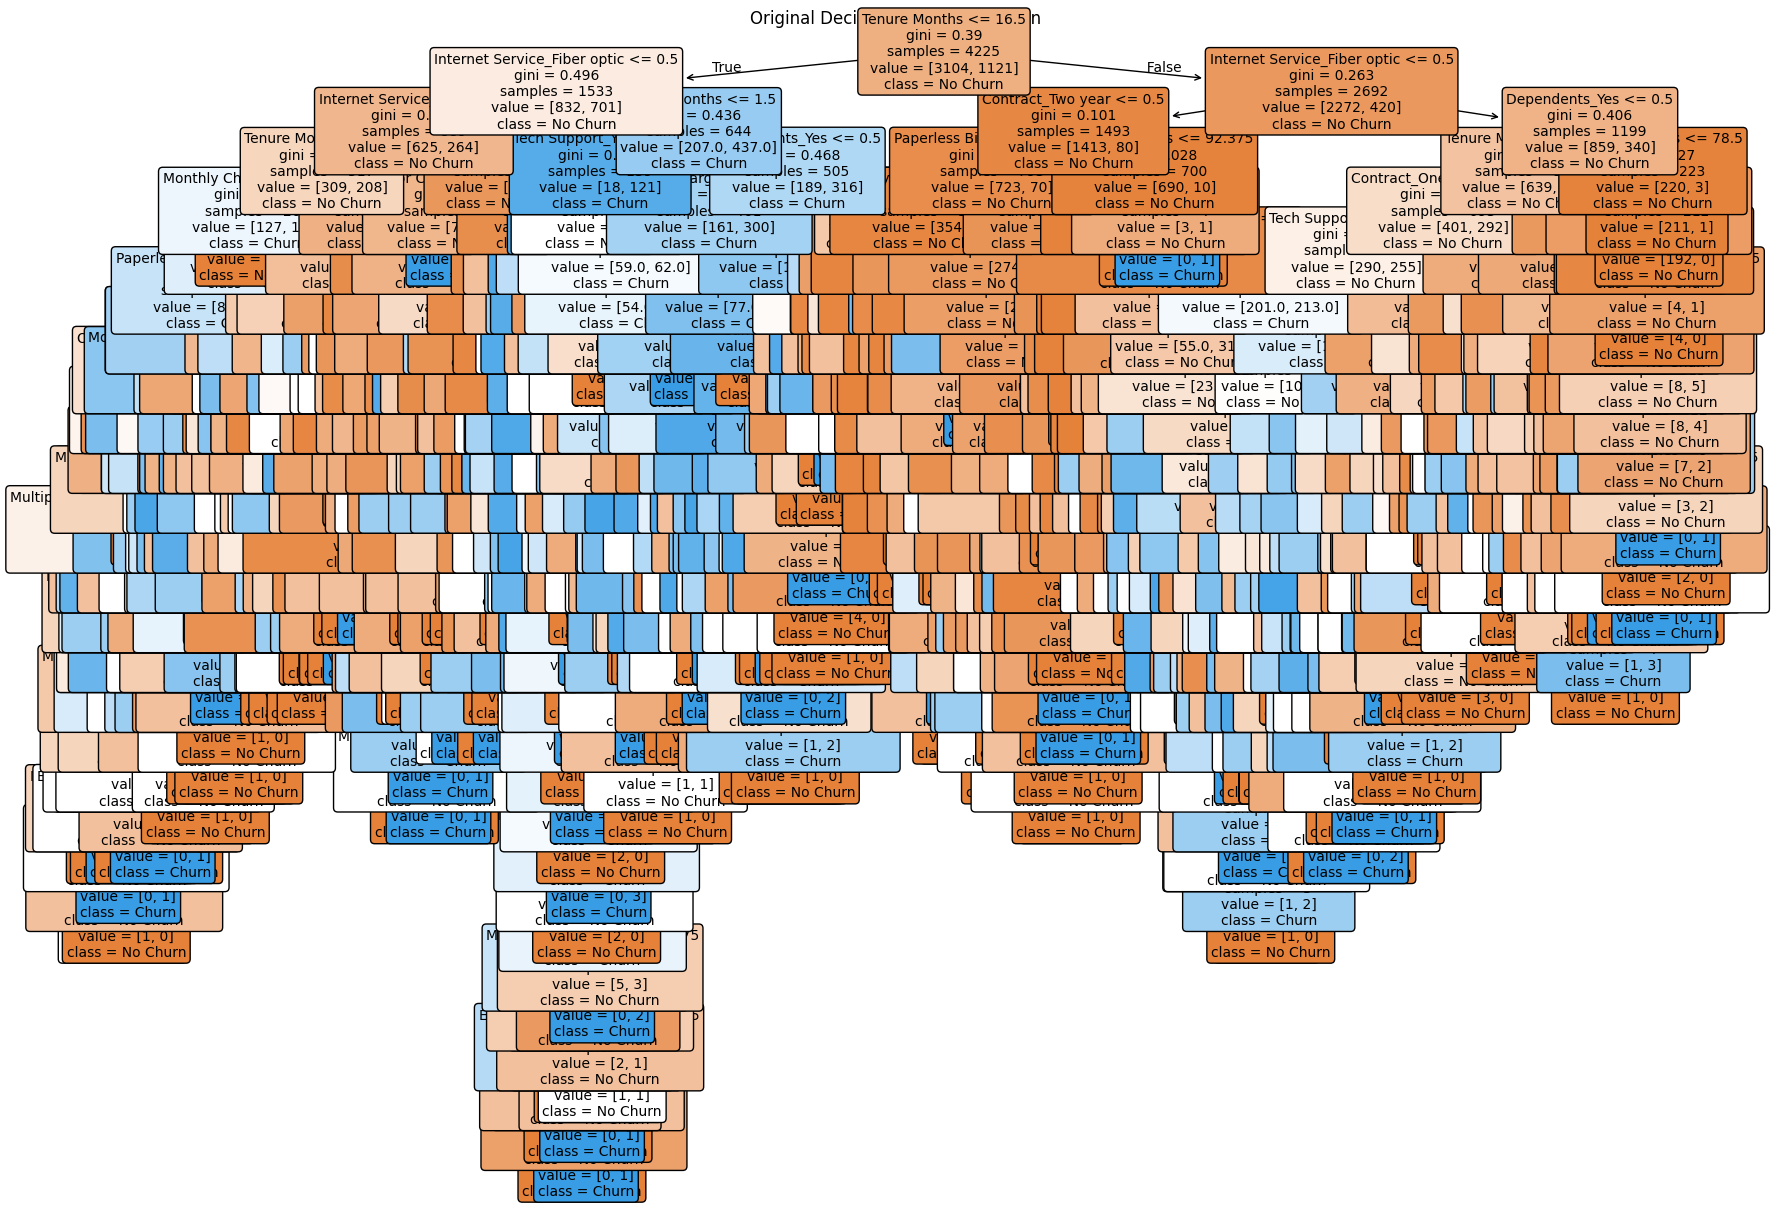

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size for better visualization
plt.figure(figsize=(20, 15))

# Plot the original decision tree
plot_tree(dt_model,
          feature_names=list(X_train.columns), # Use feature names from the training data
          class_names=['No Churn', 'Churn'], # Use meaningful class names
          filled=True, # Color nodes to indicate the majority class
          rounded=True, # Round node corners
          fontsize=10) # Adjust font size for readability

plt.title('Original Decision Tree Visualization')
plt.show()

4. How many splits and rules does the tree have?


5. Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.


6. Comment on the model performance.  What did you observe in the results?


In [ ]:
# The number of splits in a decision tree is the number of internal nodes.
# This is equal to the total number of nodes minus the number of leaf nodes.
# We can access the tree structure from the tuned_dt_model.tree_ attribute.

tree_ = dt_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves

number_of_splits = total_nodes - leaf_nodes

print(f"The decision tree has {number_of_splits} splits (internal nodes).")
print(f"The decision tree has {leaf_nodes} leaves.")

The decision tree has 879 splits (internal nodes).
The decision tree has 880 leaves.


The tree has 879 splits and 880 leaves

That's a big tree! How well does it perform?

In [ ]:
from sklearn.metrics import confusion_matrix

# Predictions on training set
y_train_pred = dt_model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)

# Predictions on validation set
y_val_pred = dt_model.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)

# Predictions on test set
y_test_pred = dt_model.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix - Training Set:")
print(cm_train)

print("\nConfusion Matrix - Validation Set:")
print(cm_val)

print("\nConfusion Matrix - Test Set:")
print(cm_test)

Confusion Matrix - Training Set:
[[3104    0]
 [   9 1112]]

Confusion Matrix - Validation Set:
[[895 166]
 [171 177]]

Confusion Matrix - Test Set:
[[820 189]
 [189 211]]


In [ ]:
The confusion matrices show how well the model performed on each set. Let's look at other classification metrics like accuracy, precision, recall, and F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for Training Set
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

print("Training Set Metrics:")
print(f"  Accuracy: {accuracy_train:.4f}")
print(f"  Precision: {precision_train:.4f}")
print(f"  Recall: {recall_train:.4f}")
print(f"  F1-Score: {f1_train:.4f}")

# Calculate metrics for Validation Set
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)

print("\nValidation Set Metrics:")
print(f"  Accuracy: {accuracy_val:.4f}")
print(f"  Precision: {precision_val:.4f}")
print(f"  Recall: {recall_val:.4f}")
print(f"  F1-Score: {f1_val:.4f}")


# Calculate metrics for Test Set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {accuracy_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall: {recall_test:.4f}")
print(f"  F1-Score: {f1_test:.4f}")

Training Set Metrics:
  Accuracy: 0.9979
  Precision: 1.0000
  Recall: 0.9920
  F1-Score: 0.9960

Validation Set Metrics:
  Accuracy: 0.7608
  Precision: 0.5160
  Recall: 0.5086
  F1-Score: 0.5123

Test Set Metrics:
  Accuracy: 0.7317
  Precision: 0.5275
  Recall: 0.5275
  F1-Score: 0.5275


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Assuming 'tuned_dt_model' is your trained Decision Tree Classifier model
# Assuming 'X_train' is your training feature DataFrame (for feature names)

def get_decision_path_rules(tree, feature_names, node_id, current_rule, class_names):
    """Recursively gets the decision path rules and probabilities for each leaf node."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get the class distribution (counts) and total samples at the leaf
        value = tree.value[node_id][0]
        total_samples_at_leaf = np.sum(value)

        # Calculate probabilities for each class
        probabilities = value / total_samples_at_leaf

        # Format the probabilities for printing
        prob_strings = [f"{class_names[i]}: {probabilities[i]:.4f}" for i in range(len(class_names))]
        prob_output = ", ".join(prob_strings)

        print(f"Rule: {current_rule} -> Probabilities: {prob_output}")
        return

    # If it's an internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Rule for the left child
    left_rule = f"{current_rule} AND {feature_name} <= {threshold:.2f}" if current_rule else f"{feature_name} <= {threshold:.2f}"
    get_decision_path_rules(tree, feature_names, left_child, left_rule, class_names)

    # Rule for the right child
    right_rule = f"{current_rule} AND {feature_name} > {threshold:.2f}" if current_rule else f"{feature_name} > {threshold:.2f}"
    get_decision_path_rules(tree, feature_names, right_child, right_rule, class_names)

# Get the tree structure and feature names
tree_structure = tuned_dt_model.tree_
feature_names = list(X_train.columns)
class_names = ['No Personal Loan', 'Personal Loan'] # Define your class names

print("Logical rules and probabilities for each leaf of the tuned decision tree:")
# Start the recursion from the root node (node_id 0) with an empty initial rule
get_decision_path_rules(tree_structure, feature_names, 0, "", class_names)

Logical rules and probabilities for each leaf of the tuned decision tree:
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months <= 4.50 AND Monthly Charges <= 69.65 AND Tech Support_Yes <= 0.50 -> Probabilities: No Personal Loan: 0.4171, Personal Loan: 0.5829
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months <= 4.50 AND Monthly Charges <= 69.65 AND Tech Support_Yes > 0.50 -> Probabilities: No Personal Loan: 0.6304, Personal Loan: 0.3696
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months <= 4.50 AND Monthly Charges > 69.65 -> Probabilities: No Personal Loan: 1.0000, Personal Loan: 0.0000
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months > 4.50 AND Dependents_Yes <= 0.50 AND Online Backup_Yes <= 0.50 -> Probabilities:

The rules in the model is that Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months <= 4.50 AND Monthly Charges <= 69.65 AND Tech Support_Yes <= 0.50 -> Probabilities: No Personal Loan: 0.4171, Personal Loan: 0.5829

In [ ]:
import pandas as pd

# Get the feature importances from the tuned decision tree model
feature_importances_tuned_dt = tuned_dt_model.feature_importances_

# Get the feature names from the training data (assuming X_train is consistent)
feature_names_dt = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_tuned_dt = pd.Series(feature_importances_tuned_dt, index=feature_names_dt)

# Sort the feature importances in descending order
sorted_feature_importances_tuned_dt = feature_importance_series_tuned_dt.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Decision Tree:")
print(sorted_feature_importances_tuned_dt)

Feature Importances for Tuned Decision Tree:
Tenure Months                      0.413002
Internet Service_Fiber optic       0.302240
Dependents_Yes                     0.091654
Monthly Charges                    0.059751
Internet Service_No                0.046284
Contract_One year                  0.018649
Tech Support_Yes                   0.018427
Online Security_Yes                0.014346
Paperless Billing_Yes              0.008710
Partner_Yes                        0.007459
Contract_Two year                  0.006869
Online Backup_Yes                  0.005210
Multiple Lines_Yes                 0.002953
Multiple Lines_No phone service    0.002668
Senior Citizen_Yes                 0.001279
Electronic Check_Yes               0.000499
Gender_Male                        0.000000
Device Protection_Yes              0.000000
dtype: float64


The tree's performance did well. There was definitely some overfitting with the large amount of splits and leaves and high complexity. Performance metrics like accuracy (0.9979), and F1 (0.9960) were high indicating how close to perfection the model was. Additionally, there were huge discrepancies with the training validation and test performance indicating the model didn't quite grasp the genral patterns

## Hyperparameter Tuning

7. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


8. Re-train the model with hyperparameter tuning.  How many splits and rules does the tree have?


In [ ]:
# Define the parameter grid
param_grid = {
    'max_depth': range(2, 21),
    'min_samples_split': range(2, 21),
    'min_samples_leaf': range(1, 11)
}

print("Parameter grid defined:")
print(param_grid)

Parameter grid defined:
{'max_depth': range(2, 21), 'min_samples_split': range(2, 21), 'min_samples_leaf': range(1, 11)}


9. Check the tuned model performance by partition with total accuracy, precision, recall, F1 score, and AUC.


10. How did performance change?


In [ ]:
from sklearn.model_selection import GridSearchCV

# Instantiate GridSearchCV
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)

Best hyperparameters found: {'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 17}
Best cross-validation F1-score: 0.6021017695628195


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Retrieve the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Instantiate a new Decision Tree Classifier with the best hyperparameters
tuned_dt_model = DecisionTreeClassifier(**best_params, random_state=42)

# Train the tuned model on the complete training dataset
tuned_dt_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_tuned = tuned_dt_model.predict(X_train)
cm_train_tuned = confusion_matrix(y_train, y_train_pred_tuned)

# Make predictions on validation set
y_val_pred_tuned = tuned_dt_model.predict(X_val)
cm_val_tuned = confusion_matrix(y_val, y_val_pred_tuned)

# Make predictions on test set
y_test_pred_tuned = tuned_dt_model.predict(X_test)
cm_test_tuned = confusion_matrix(y_test, y_test_pred_tuned)

print("\nConfusion Matrix - Tuned Training Set:")
print(cm_train_tuned)

print("\nConfusion Matrix - Tuned Validation Set:")
print(cm_val_tuned)

print("\nConfusion Matrix - Tuned Test Set:")
print(cm_test_tuned)

# Calculate metrics for Training Set
accuracy_train_tuned = accuracy_score(y_train, y_train_pred_tuned)
precision_train_tuned = precision_score(y_train, y_train_pred_tuned)
recall_train_tuned = recall_score(y_train, y_train_pred_tuned)
f1_train_tuned = f1_score(y_train, y_train_pred_tuned)

print("\nTuned Training Set Metrics:")
print(f"  Accuracy: {accuracy_train_tuned:.4f}")
print(f"  Precision: {precision_train_tuned:.4f}")
print(f"  Recall: {recall_train_tuned:.4f}")
print(f"  F1-Score: {f1_train_tuned:.4f}")

# Calculate metrics for Validation Set
accuracy_val_tuned = accuracy_score(y_val, y_val_pred_tuned)
precision_val_tuned = precision_score(y_val, y_val_pred_tuned)
recall_val_tuned = recall_score(y_val, y_val_pred_tuned)
f1_val_tuned = f1_score(y_val, y_val_pred_tuned)

print("\nTuned Validation Set Metrics:")
print(f"  Accuracy: {accuracy_val_tuned:.4f}")
print(f"  Precision: {precision_val_tuned:.4f}")
print(f"  Recall: {recall_val_tuned:.4f}")
print(f"  F1-Score: {f1_val_tuned:.4f}")


# Calculate metrics for Test Set
accuracy_test_tuned = accuracy_score(y_test, y_test_pred_tuned)
precision_test_tuned = precision_score(y_test, y_test_pred_tuned)
recall_test_tuned = recall_score(y_test, y_test_pred_tuned)
f1_test_tuned = f1_score(y_test, y_test_pred_tuned)

print("\nTuned Test Set Metrics:")
print(f"  Accuracy: {accuracy_test_tuned:.4f}")
print(f"  Precision: {precision_test_tuned:.4f}")
print(f"  Recall: {recall_test_tuned:.4f}")
print(f"  F1-Score: {f1_test_tuned:.4f}")

Best hyperparameters: {'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 17}

Confusion Matrix - Tuned Training Set:
[[2657  447]
 [ 369  752]]

Confusion Matrix - Tuned Validation Set:
[[899 162]
 [138 210]]

Confusion Matrix - Tuned Test Set:
[[855 154]
 [138 262]]

Tuned Training Set Metrics:
  Accuracy: 0.8069
  Precision: 0.6272
  Recall: 0.6708
  F1-Score: 0.6483

Tuned Validation Set Metrics:
  Accuracy: 0.7871
  Precision: 0.5645
  Recall: 0.6034
  F1-Score: 0.5833

Tuned Test Set Metrics:
  Accuracy: 0.7928
  Precision: 0.6298
  Recall: 0.6550
  F1-Score: 0.6422


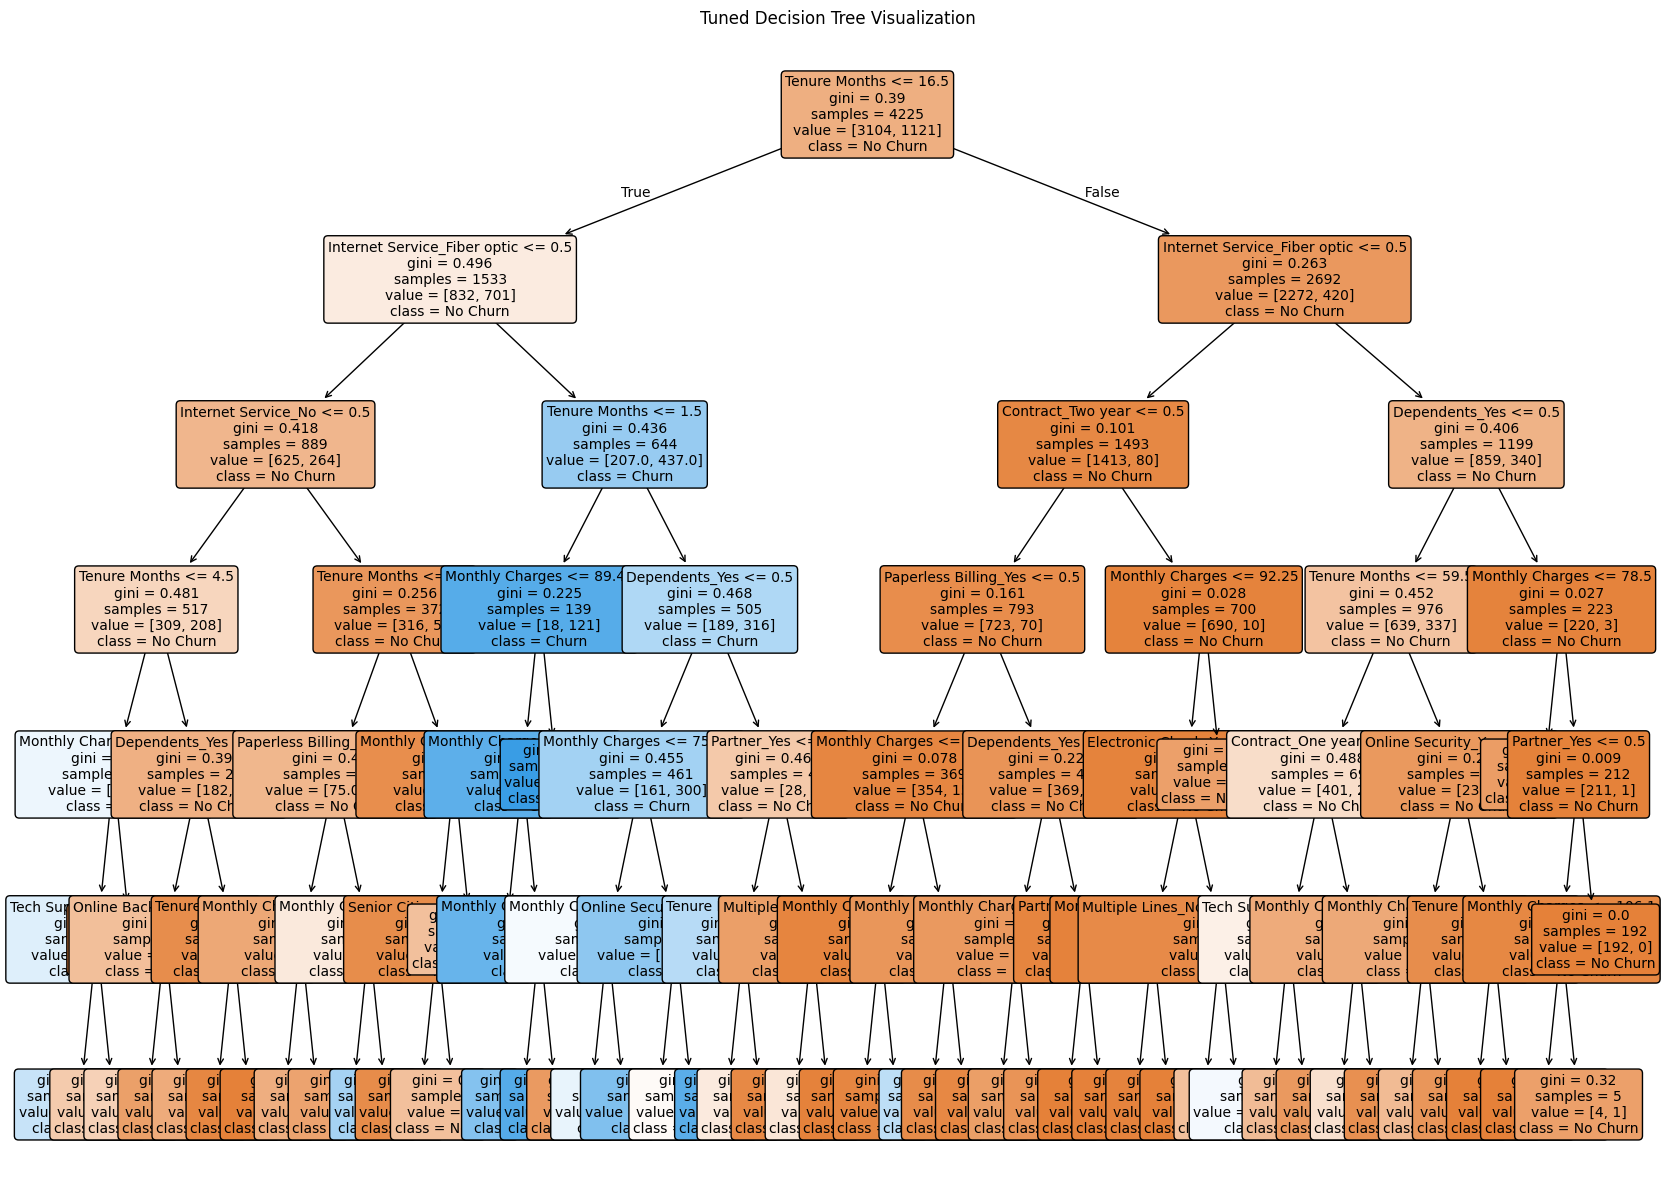

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size for better visualization
plt.figure(figsize=(20, 15))

# Plot the tuned decision tree
plot_tree(tuned_dt_model,
          feature_names=list(X_train.columns), # Use feature names from the training data
          class_names=['No Churn', 'Churn'], # Use meaningful class names
          filled=True, # Color nodes to indicate the majority class
          rounded=True, # Round node corners
          fontsize=10) # Adjust font size for readability

plt.title('Tuned Decision Tree Visualization')
plt.show()

In [ ]:
# The number of splits in a decision tree is the number of internal nodes.
# This is equal to the total number of nodes minus the number of leaf nodes.
# We can access the tree structure from the tuned_dt_model.tree_ attribute.

tree_ = tuned_dt_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves

number_of_splits = total_nodes - leaf_nodes

print(f"The tuned decision tree has {number_of_splits} splits (internal nodes).")
print(f"The tuned decision tree has {leaf_nodes} leaves.")

The tuned decision tree has 50 splits (internal nodes).
The tuned decision tree has 51 leaves.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Assuming 'tuned_dt_model' is your trained Decision Tree Classifier model
# Assuming 'X_train' is your training feature DataFrame (for feature names)

def get_decision_path_rules(tree, feature_names, node_id, current_rule, class_names):
    """Recursively gets the decision path rules and probabilities for each leaf node."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get the class distribution (counts) and total samples at the leaf
        value = tree.value[node_id][0]
        total_samples_at_leaf = np.sum(value)

        # Calculate probabilities for each class
        probabilities = value / total_samples_at_leaf

        # Format the probabilities for printing
        prob_strings = [f"{class_names[i]}: {probabilities[i]:.4f}" for i in range(len(class_names))]
        prob_output = ", ".join(prob_strings)

        print(f"Rule: {current_rule} -> Probabilities: {prob_output}")
        return

    # If it's an internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Rule for the left child
    left_rule = f"{current_rule} AND {feature_name} <= {threshold:.2f}" if current_rule else f"{feature_name} <= {threshold:.2f}"
    get_decision_path_rules(tree, feature_names, left_child, left_rule, class_names)

    # Rule for the right child
    right_rule = f"{current_rule} AND {feature_name} > {threshold:.2f}" if current_rule else f"{feature_name} > {threshold:.2f}"
    get_decision_path_rules(tree, feature_names, right_child, right_rule, class_names)

# Get the tree structure and feature names
tree_structure = tuned_dt_model.tree_
feature_names = list(X_train.columns)
class_names = ['No Personal Loan', 'Personal Loan'] # Define your class names

print("Logical rules and probabilities for each leaf of the tuned decision tree:")
# Start the recursion from the root node (node_id 0) with an empty initial rule
get_decision_path_rules(tree_structure, feature_names, 0, "", class_names)

Logical rules and probabilities for each leaf of the tuned decision tree:
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months <= 4.50 AND Monthly Charges <= 69.65 AND Tech Support_Yes <= 0.50 -> Probabilities: No Personal Loan: 0.4171, Personal Loan: 0.5829
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months <= 4.50 AND Monthly Charges <= 69.65 AND Tech Support_Yes > 0.50 -> Probabilities: No Personal Loan: 0.6304, Personal Loan: 0.3696
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months <= 4.50 AND Monthly Charges > 69.65 -> Probabilities: No Personal Loan: 1.0000, Personal Loan: 0.0000
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 AND Internet Service_No <= 0.50 AND Tenure Months > 4.50 AND Dependents_Yes <= 0.50 AND Online Backup_Yes <= 0.50 -> Probabilities:

In [ ]:
import pandas as pd

# Get the feature importances from the tuned decision tree model
feature_importances_tuned_dt = tuned_dt_model.feature_importances_

# Get the feature names from the training data (assuming X_train is consistent)
feature_names_dt = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_tuned_dt = pd.Series(feature_importances_tuned_dt, index=feature_names_dt)

# Sort the feature importances in descending order
sorted_feature_importances_tuned_dt = feature_importance_series_tuned_dt.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Decision Tree:")
print(sorted_feature_importances_tuned_dt)

Feature Importances for Tuned Decision Tree:
Tenure Months                      0.413002
Internet Service_Fiber optic       0.302240
Dependents_Yes                     0.091654
Monthly Charges                    0.059751
Internet Service_No                0.046284
Contract_One year                  0.018649
Tech Support_Yes                   0.018427
Online Security_Yes                0.014346
Paperless Billing_Yes              0.008710
Partner_Yes                        0.007459
Contract_Two year                  0.006869
Online Backup_Yes                  0.005210
Multiple Lines_Yes                 0.002953
Multiple Lines_No phone service    0.002668
Senior Citizen_Yes                 0.001279
Electronic Check_Yes               0.000499
Gender_Male                        0.000000
Device Protection_Yes              0.000000
dtype: float64


The model's performance after hyperparameter tuning was much more simplified, easier to read and understand. The best features for this model are tenure months and internet service_fiber optic

#LOAD THE DATA - SPOTIFY

12. Read in the Spotify dataset and determine how many rows and columns it has.


In [ ]:
# read data
# on the lefthand side, navigate to your data and copy the path
# The UnicodeDecodeError indicates a problem with the file encoding.
# Trying 'latin1' encoding as it often resolves such issues.
df = pd.read_csv('/content/drive/MyDrive/OPIM 5604 Python/Datasets/spotify-2023.csv', encoding='latin1')

In [ ]:
# shape
# shows how many rows and columns
# this sample has 1000 rows and 10 columns
df.shape

(953, 24)

This dataset has 953 rows and 24 columns

In [ ]:
# Preview
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  ...  bpm key   mode  \
0                147  141381703               

13. The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  Hint: if needed, drop a row of problematic data to get it to convert properly.


In [ ]:
# Before conversion, check for non-numeric values in 'streams' to understand the error
print("Original 'streams' column dtype:", df['streams'].dtype)
non_numeric_streams = df[pd.to_numeric(df['streams'], errors='coerce').isna()]['streams']
if not non_numeric_streams.empty:
    print("\nNon-numeric values found in 'streams' column before conversion (first 5 shown):\n", non_numeric_streams.head())

# Convert 'streams' column to numeric, coercing errors to NaN
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# Drop rows where 'streams' became NaN after conversion, as these are the problematic entries
df.dropna(subset=['streams'], inplace=True)

print("\n'streams' column dtype after conversion and dropping NaNs:", df['streams'].dtype)
print("DataFrame shape after cleaning 'streams' column:", df.shape)

Original 'streams' column dtype: object

Non-numeric values found in 'streams' column before conversion (first 5 shown):
 574    BPM110KeyAModeMajorDanceability53Valence75Ener...
Name: streams, dtype: object

'streams' column dtype after conversion and dropping NaNs: float64
DataFrame shape after cleaning 'streams' column: (952, 24)


14. Partition the data into a 60/20/20 split.


In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable for Spotify data
target = 'streams'

# Define features by dropping the target variable and identifier columns
# Based on the df.head(), 'track_name' and 'artist(s)_name' are identifiers.
# 'key' and 'mode' are categorical features that will be one-hot encoded.
features = df.drop([target, 'track_name', 'artist(s)_name'], axis=1)
target_variable = df[target]

# Split the data into 80% (training + validation) and 20% test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(features, target_variable, test_size=0.2, random_state=42)

# Split the 80% (X_train_raw from above) into 60% training and 20% validation
# To get a 60% train and 20% validation from the original 100% data, test_size=0.25 (0.25 * 0.8 = 0.2)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_raw, y_train, test_size=0.25, random_state=42)

# Identify categorical columns for one-hot encoding
categorical_cols = X_train_raw.select_dtypes(include='object').columns

# Apply one-hot encoding to training, validation, and test sets
X_train = pd.get_dummies(X_train_raw, columns=categorical_cols, drop_first=False)
X_val = pd.get_dummies(X_val_raw, columns=categorical_cols, drop_first=False)
X_test = pd.get_dummies(X_test_raw, columns=categorical_cols, drop_first=False)

# Ensure all splits have the same columns after one-hot encoding (important for consistent modeling)
X_train_cols = X_train.columns
X_val = X_val.reindex(columns=X_train_cols, fill_value=0)
X_test = X_test.reindex(columns=X_train_cols, fill_value=0)

# Print the shapes of the resulting datasets
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (570, 432) (570,)
Validation set shape: (191, 432) (191,)
Test set shape: (191, 432) (191,)


# Regression Trees - Manual Math

15. Build a regression tree model to predict streams using all predictors.


In [ ]:
# Calculate the overall variance of the target variable in the training set
overall_variance = y_train.var()

# Print the calculated overall variance
print(f"Overall Variance of streams: {overall_variance:.4f}")

Overall Variance of Price: 360044482707579264.0000


In [ ]:
# Create a dictionary to store potential split points for each feature
potential_splits_dict = {}

# Iterate through each column (feature) in the X_train DataFrame
for feature in X_train.columns:
    # Check the data type of the feature
    if X_train[feature].dtype in ['int64', 'float64']:
        # For numerical features, find unique values, sort them, and calculate midpoints
        unique_values = sorted(X_train[feature].unique())
        potential_splits = [(unique_values[i] + unique_values[i+1]) / 2 for i in range(len(unique_values) - 1)]
        potential_splits_dict[feature] = potential_splits
    elif X_train[feature].dtype == 'bool':
        # For boolean/dummy features, the split is typically at 0.5
        potential_splits_dict[feature] = [0.5]
    # Note: If there are other categorical types that haven't been dummified,
    # we would need to handle them differently (e.g., by considering all possible
    # groupings of categories). For this dataset, dummy variables handle categoricals.


# Display the potential split points found for each feature
for feature, splits in potential_splits_dict.items():
    print(f"Potential splits for '{feature}': {splits[:5]}...") # Print only the first few splits for brevity

Potential splits for 'artist_count': [np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(5.5)]...
Potential splits for 'released_year': [np.float64(1946.0), np.float64(1951.0), np.float64(1954.5), np.float64(1960.0), np.float64(1965.5)]...
Potential splits for 'released_month': [np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(5.5)]...
Potential splits for 'released_day': [np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(5.5)]...
Potential splits for 'in_spotify_playlists': [np.float64(32.5), np.float64(46.0), np.float64(62.5), np.float64(72.0), np.float64(81.5)]...
Potential splits for 'in_spotify_charts': [np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5)]...
Potential splits for 'in_apple_playlists': [np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5)]...
Potential splits for 'in_apple_charts': [np.float64(0.5), np.float64(1.5), n

In [ ]:
# Calculate total instances for the current training set
total_instances = len(y_train)
overall_best_reduction = -float('inf')
overall_best_feature = None
overall_best_threshold = None

# Calculate the overall variance (from previous calculation)
overall_variance = y_train.var()

# Create a list to store the results for each feature
results = []

# Iterate through all predictor variables
for feature, potential_splits in potential_splits_dict.items():

    best_reduction_for_feature = -float('inf') # Use -inf as we are maximizing reduction
    best_threshold_for_feature = None

    # Iterate through each potential split point for the current feature
    for threshold in potential_splits:
        # Split the training data based on the current threshold
        left_split_indices = X_train[X_train[feature] <= threshold].index
        right_split_indices = X_train[X_train[feature] > threshold].index

        y_train_left_split = y_train.loc[left_split_indices]
        y_train_right_split = y_train.loc[right_split_indices]

        total_left = len(y_train_left_split)
        if total_left > 0:
            variance_left = y_train_left_split.var()
        else:
            variance_left = 0

        total_right = len(y_train_right_split)
        if total_right > 0:
            variance_right = y_train_right_split.var()
        else:
            variance_right = 0

        # Handle cases where a split results in an empty set (variance is undefined/NaN)
        if total_left == 0 or total_right == 0:
            weighted_variance_split = float('inf') # Or handle as appropriate, e.g., skip this split
        else:
             weighted_variance_split = (total_left / total_instances) * variance_left + (total_right / total_instances) * variance_right


        reduction_in_variance = overall_variance - weighted_variance_split

        if reduction_in_variance > best_reduction_for_feature:
             best_reduction_for_feature = reduction_in_variance
             best_threshold_for_feature = threshold

    # Store the results for the current feature
    results.append({
        'Feature': feature,
        'Best Threshold': best_threshold_for_feature,
        'Variance Reduction': best_reduction_for_feature
    })

    # Update overall best if the best for this feature is better
    if best_reduction_for_feature > overall_best_reduction:
        overall_best_reduction = best_reduction_for_feature
        overall_best_feature = feature
        overall_best_threshold = best_threshold_for_feature

# Convert the results to a pandas DataFrame and display
results_df = pd.DataFrame(results)
display(results_df.round(4)) # Display with 4 decimal places for clarity


print(f"\nOverall best first split for regression tree:")
print(f"  Feature: {overall_best_feature}")
print(f"  Threshold: {overall_best_threshold}")
print(f"  Maximum Reduction in Variance: {overall_best_reduction:.4f}")

,Feature,Best Threshold,Variance Reduction
0,artist_count,3.5,2.431205e+15
1,released_year,2020.5,1.348631e+17
2,released_month,1.5,7.677320e+15
3,released_day,1.5,1.344775e+16
4,in_spotify_playlists,11020.5,2.072084e+17
...,...,...,...
427,key_F#,0.5,-3.596294e+14
428,key_G,0.5,-4.663894e+14
429,key_G#,0.5,2.787632e+14
430,mode_Major,0.5,-6.283885e+14



Overall best first split for regression tree:
  Feature: in_spotify_playlists
  Threshold: 11020.5
  Maximum Reduction in Variance: 207208436073848224.0000


#Regression Trees

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor
# We can start with default parameters for an initial model
reg_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model on the training data
reg_tree_model.fit(X_train, y_train)

print("Regression Tree model trained successfully.")

Regression Tree model trained successfully.


18. Comment on the model performance.  What did you observe in the results?


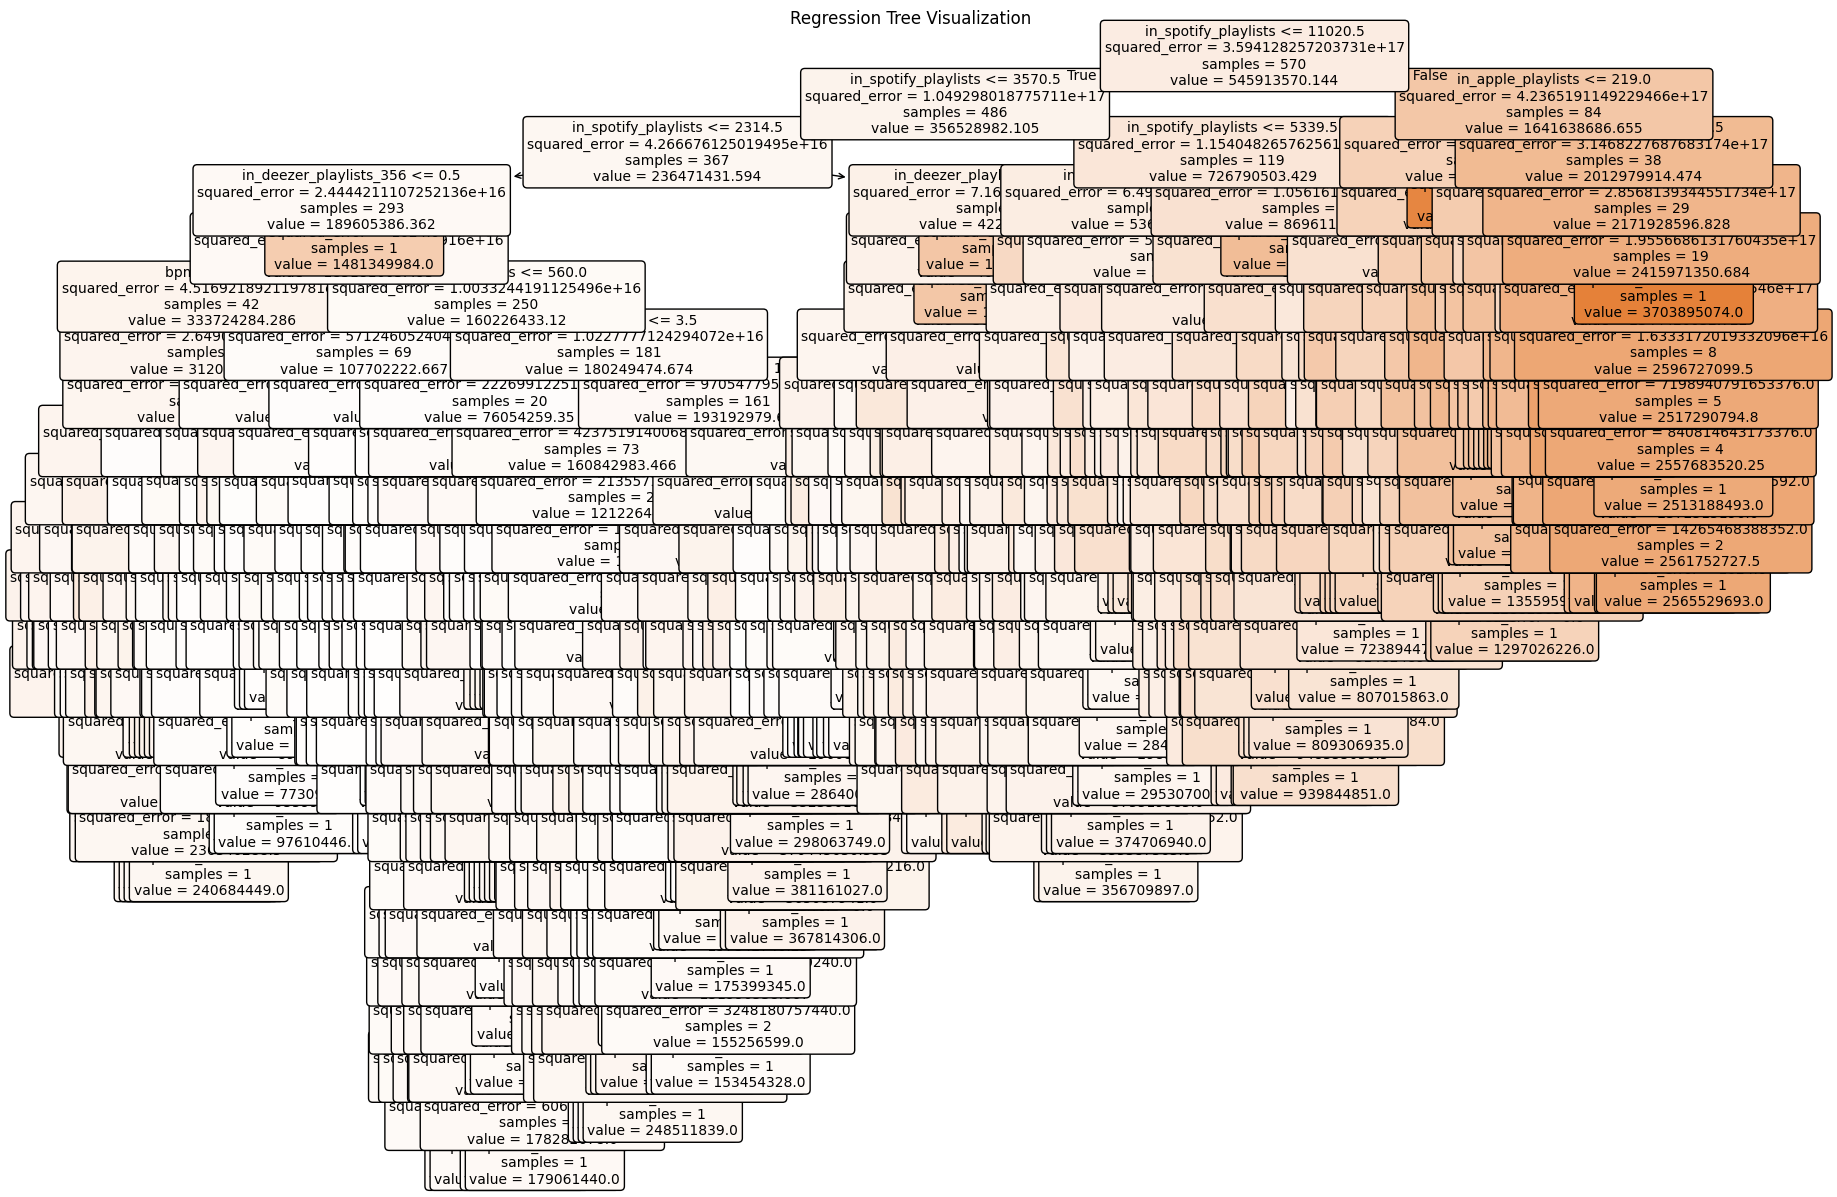

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size for better visualization
plt.figure(figsize=(20, 15))

# Plot the regression tree
plot_tree(reg_tree_model,
          feature_names=list(X_train.columns), # Use feature names from the training data
          filled=True, # Color nodes based on the predicted value
          rounded=True, # Round node corners
          fontsize=10) # Adjust font size for readability

plt.title('Regression Tree Visualization')
plt.show()

16. How many splits and rules does the tree have?


17. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate the number of splits and leaves
tree_ = reg_tree_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves
number_of_splits = total_nodes - leaf_nodes

print(f"The regression tree has {number_of_splits} splits (internal nodes).")
print(f"The regression tree has {leaf_nodes} leaves.")

# Make predictions on training set
y_train_pred_reg = reg_tree_model.predict(X_train)

# Make predictions on validation set
y_val_pred_reg = reg_tree_model.predict(X_val)

# Make predictions on test set
y_test_pred_reg = reg_tree_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_reg = np.sqrt(mean_squared_error(y_train, y_train_pred_reg))
r2_train_reg = r2_score(y_train, y_train_pred_reg)

print("\nRegression Tree Performance on Training Set:")
print(f"  RMSE: {rmse_train_reg:.4f}")
print(f"  R-squared: {r2_train_reg:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_reg = np.sqrt(mean_squared_error(y_val, y_val_pred_reg))
r2_val_reg = r2_score(y_val, y_val_pred_reg)

print("\nRegression Tree Performance on Validation Set:")
print(f"  RMSE: {rmse_val_reg:.4f}")
print(f"  R-squared: {r2_val_reg:.4f}")

# Calculate and print metrics for Test Set
rmse_test_reg = np.sqrt(mean_squared_error(y_test, y_test_pred_reg))
r2_test_reg = r2_score(y_test, y_test_pred_reg)

print("\nRegression Tree Performance on Test Set:")
print(f"  RMSE: {rmse_test_reg:.4f}")
print(f"  R-squared: {r2_test_reg:.4f}")

The regression tree has 569 splits (internal nodes).
The regression tree has 570 leaves.

Regression Tree Performance on Training Set:
  RMSE: 0.0000
  R-squared: 1.0000

Regression Tree Performance on Validation Set:
  RMSE: 313545002.5535
  R-squared: 0.6424

Regression Tree Performance on Test Set:
  RMSE: 286998774.2807
  R-squared: 0.6635


The dataset has 569 splits and 570 leaves

The tree is very hard and complicated to read because of the amount of splits it has. There is definitely some overfitting

## Hyperparameter Tuning

Time to make this tree smaller and fix the overfitting.

20. Re-train the model with hyperparameter tuning.  How many splits and rules does the tree have?


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, make_scorer

# Define the parameter grid
param_grid_reg = {
    'max_depth': range(2, 21),
    'min_samples_split': range(2, 21),
    'min_samples_leaf': range(1, 11)
}

# Create a scorer for negative mean squared error (GridSearchCV maximizes scores)
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Instantiate GridSearchCV
# Use the original reg_tree_model as the estimator
grid_search_reg = GridSearchCV(reg_tree_model, param_grid_reg, cv=5, scoring=neg_mse_scorer, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_reg.fit(X_train, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found:", grid_search_reg.best_params_)
# Convert the best score back to positive MSE or RMSE for easier interpretation
best_mse = -grid_search_reg.best_score_
best_rmse = np.sqrt(best_mse)
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

Best hyperparameters found: {'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 2}
Best cross-validation RMSE: 316430516.6213


21. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


22. How did performance change?


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Retrieve the best hyperparameters for the regression tree
best_params_reg = grid_search_reg.best_params_
print("Best hyperparameters for Regression Tree:", best_params_reg)

# Instantiate a new Decision Tree Regressor with the best hyperparameters
tuned_reg_tree_model = DecisionTreeRegressor(**best_params_reg, random_state=42)

# Train the tuned model on the complete training dataset
tuned_reg_tree_model.fit(X_train, y_train)

# Calculate the number of splits and leaves for the tuned tree
tree_tuned_reg = tuned_reg_tree_model.tree_
total_nodes_tuned_reg = tree_tuned_reg.node_count
leaf_nodes_tuned_reg = tree_tuned_reg.n_leaves
number_of_splits_tuned_reg = total_nodes_tuned_reg - leaf_nodes_tuned_reg

print(f"\nTuned Regression Tree:")
print(f"  Number of splits (internal nodes): {number_of_splits_tuned_reg}")
print(f"  Number of leaves: {leaf_nodes_tuned_reg}")


# Make predictions on training set
y_train_pred_tuned_reg = tuned_reg_tree_model.predict(X_train)

# Make predictions on validation set
y_val_pred_tuned_reg = tuned_reg_tree_model.predict(X_val)

# Make predictions on test set
y_test_pred_tuned_reg = tuned_reg_tree_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_tuned_reg = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned_reg))
r2_train_tuned_reg = r2_score(y_train, y_train_pred_tuned_reg)

print("\nTuned Regression Tree Performance on Training Set:")
print(f"  RMSE: {rmse_train_tuned_reg:.4f}")
print(f"  R-squared: {r2_train_tuned_reg:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_tuned_reg = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned_reg))
r2_val_tuned_reg = r2_score(y_val, y_val_pred_tuned_reg)

print("\nTuned Regression Tree Performance on Validation Set:")
print(f"  RMSE: {rmse_val_tuned_reg:.4f}")
print(f"  R-squared: {r2_val_tuned_reg:.4f}")


# Calculate and print metrics for Test Set
rmse_test_tuned_reg = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned_reg))
r2_test_tuned_reg = r2_score(y_test, y_test_pred_tuned_reg)

print("\nTuned Regression Tree Performance on Test Set:")
print(f"  RMSE: {rmse_test_tuned_reg:.4f}")
print(f"  R-squared: {r2_test_tuned_reg:.4f}")

Best hyperparameters for Regression Tree: {'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 2}

Tuned Regression Tree:
  Number of splits (internal nodes): 39
  Number of leaves: 40

Tuned Regression Tree Performance on Training Set:
  RMSE: 209176828.0798
  R-squared: 0.8783

Tuned Regression Tree Performance on Validation Set:
  RMSE: 248260317.0806
  R-squared: 0.7758

Tuned Regression Tree Performance on Test Set:
  RMSE: 261526464.7419
  R-squared: 0.7206


The model after tuning definitely has some reduced overfitting but there still less generalization. RMSE decreased while R-squared increased meaning improved performance. Lastly, the complexity of the model also decreased.

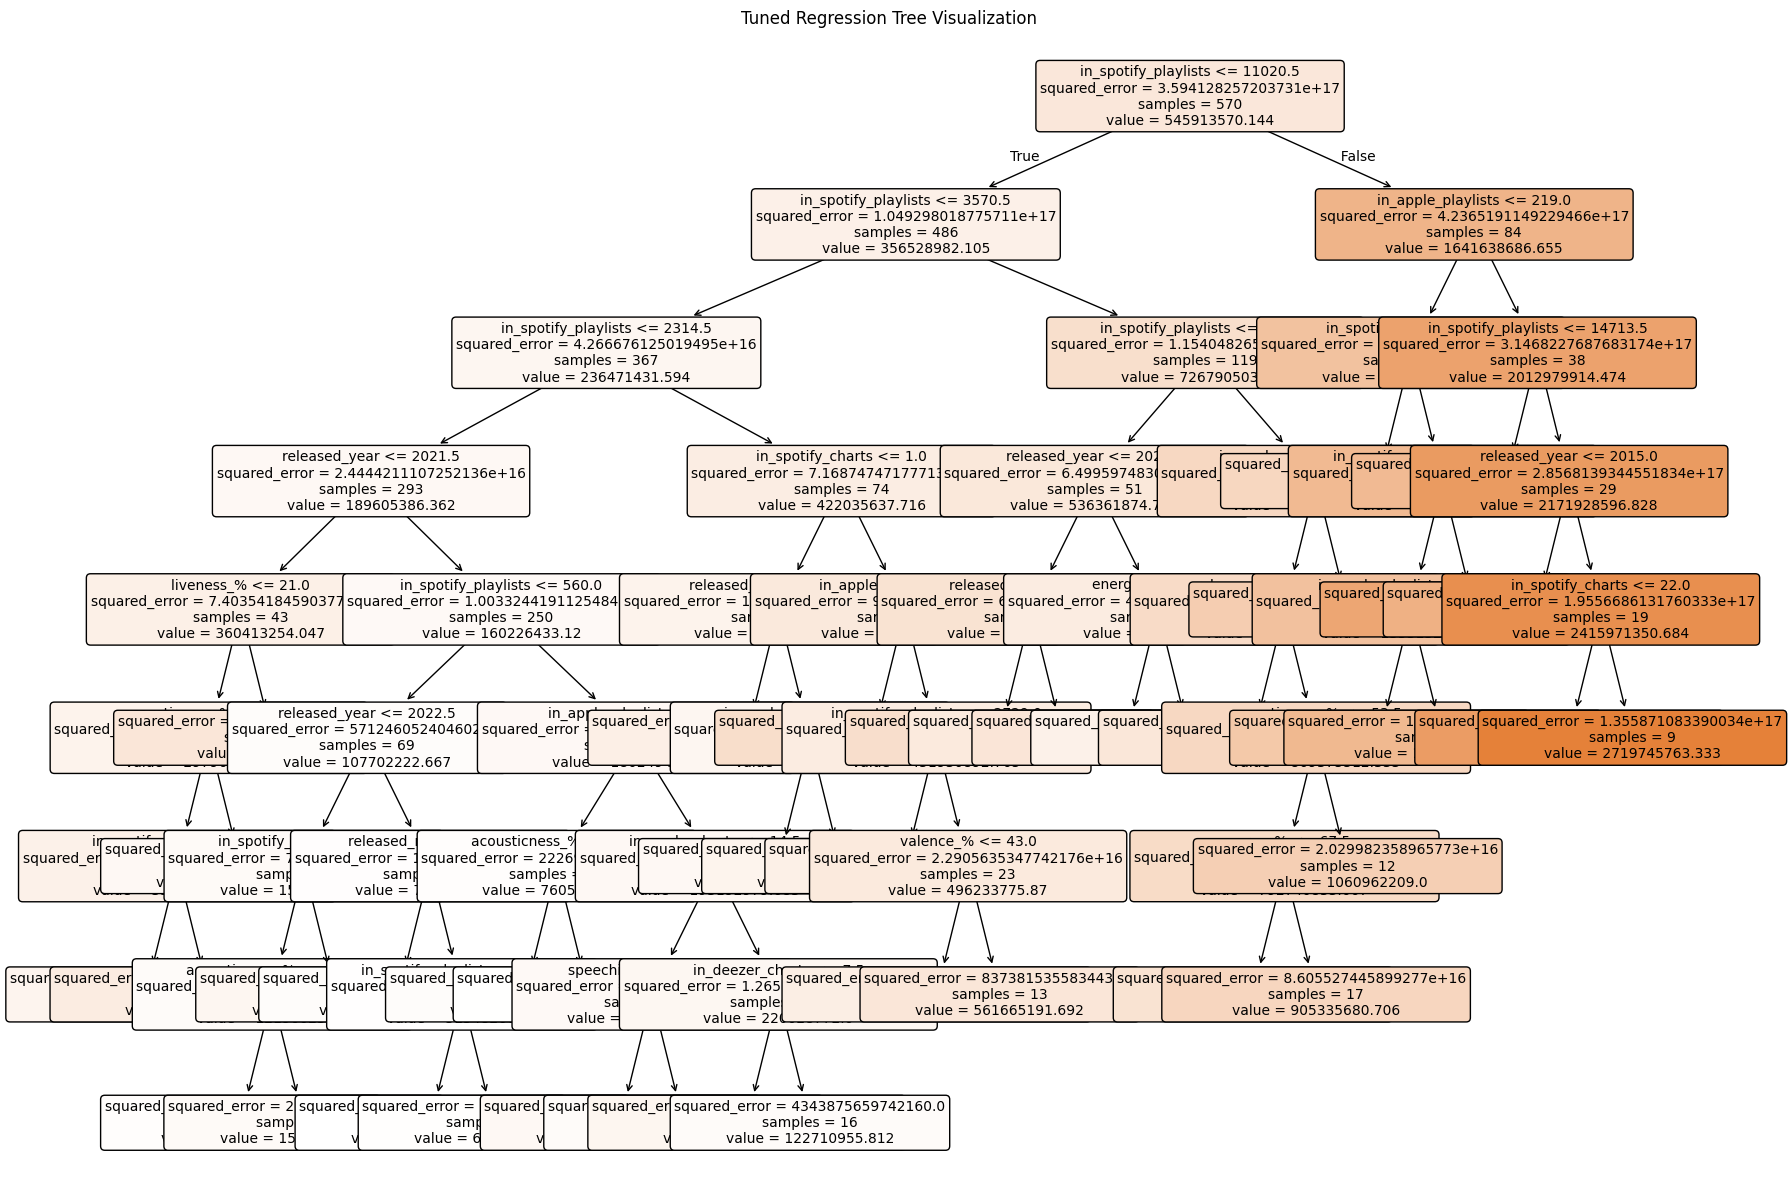

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size for better visualization
plt.figure(figsize=(20, 15))

# Plot the tuned regression tree
plot_tree(tuned_reg_tree_model,
          feature_names=list(X_train.columns), # Use feature names from the training data
          filled=True, # Color nodes based on the predicted value
          rounded=True, # Round node corners
          fontsize=10) # Adjust font size for readability

plt.title('Tuned Regression Tree Visualization')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Assuming 'tuned_reg_tree_model' is your trained Decision Tree Regressor model
# Assuming 'X_train' is your training feature DataFrame (for feature names)

def get_regression_path_rules(tree, feature_names, node_id, current_rule):
    """Recursively gets the decision path rules and predicted values for each leaf node in a regression tree."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get the predicted value (mean of the target variable) at the leaf
        predicted_value = tree.value[node_id][0][0]
        print(f"Rule: {current_rule} -> Predicted Value: {predicted_value:.4f}")
        return

    # If it's an internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Rule for the left child
    left_rule = f"{current_rule} AND {feature_name} <= {threshold:.2f}" if current_rule else f"{feature_name} <= {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, left_child, left_rule)

    # Rule for the right child
    right_rule = f"{current_rule} AND {feature_name} > {threshold:.2f}" if current_rule else f"{feature_name} > {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, right_child, right_rule)

# Get the tree structure and feature names
tree_structure_reg = tuned_reg_tree_model.tree_
feature_names_reg = list(X_train.columns)

print("Logical rules and predicted values for each leaf of the tuned regression tree:")
# Start the recursion from the root node (node_id 0) with an empty initial rule
get_regression_path_rules(tree_structure_reg, feature_names_reg, 0, "")

Logical rules and predicted values for each leaf of the tuned regression tree:
Rule: in_spotify_playlists <= 11020.50 AND in_spotify_playlists <= 3570.50 AND in_spotify_playlists <= 2314.50 AND released_year <= 2021.50 AND liveness_% <= 21.00 AND acousticness_% <= 51.00 AND in_spotify_charts <= 5.00 -> Predicted Value: 272751415.2000
Rule: in_spotify_playlists <= 11020.50 AND in_spotify_playlists <= 3570.50 AND in_spotify_playlists <= 2314.50 AND released_year <= 2021.50 AND liveness_% <= 21.00 AND acousticness_% <= 51.00 AND in_spotify_charts > 5.00 -> Predicted Value: 445997118.2222
Rule: in_spotify_playlists <= 11020.50 AND in_spotify_playlists <= 3570.50 AND in_spotify_playlists <= 2314.50 AND released_year <= 2021.50 AND liveness_% <= 21.00 AND acousticness_% > 51.00 -> Predicted Value: 191949134.3333
Rule: in_spotify_playlists <= 11020.50 AND in_spotify_playlists <= 3570.50 AND in_spotify_playlists <= 2314.50 AND released_year <= 2021.50 AND liveness_% > 21.00 -> Predicted Value:

23. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


In [ ]:
import pandas as pd

# Get the feature importances from the tuned regression tree model
feature_importances = tuned_reg_tree_model.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# Sort the feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Regression Tree:")
print(sorted_feature_importances)

Feature Importances for Tuned Regression Tree:
in_spotify_playlists         0.844829
in_apple_playlists           0.063926
released_year                0.035450
in_spotify_charts            0.034989
energy_%                     0.004876
                               ...   
in_deezer_playlists_3,394    0.000000
in_deezer_playlists_3        0.000000
in_deezer_playlists_298      0.000000
in_deezer_playlists_291      0.000000
in_deezer_playlists_328      0.000000
Length: 432, dtype: float64


in_spotify_playlists and in_apple_playlists are the two more important features.